# Automatic Modulation Classification with SVM

Given a chunk of unknown IQ data, can we automatically identify what modulation scheme was used?

This notebook trains a Support Vector Machine (SVM) classifier on the **RadioML 2016.10A** dataset and validates it on a real KiwiSDR AM recording. Features are derived directly from the DSP math in the demodulation pipeline — instantaneous amplitude, phase, and frequency statistics.

In [49]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from src.data_tools.data_loaders import load_radioml_2016_10a

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Feature Extraction

Rather than feeding raw IQ samples to the classifier, we extract **interpretable statistical features** grounded in DSP theory:

| Feature | Formula | Why it matters |
|---------|---------|----------------|
| Amplitude variance | $\text{Var}(x[n])$ | AM has high variance; FM has low (constant envelope) |
| Amplitude kurtosis | $\text{Kurt}(x[n])$ | QAM16 vs QAM64 differ in constellation density |
| Phase variance | $\text{Var}(\Delta\phi[n])$ | FM/PSK have high phase variance; AM has low |
| Freq variance | $\text{Var}(\Delta^2\phi[n])$ | FM has high instantaneous frequency deviation |
| Freq kurtosis | $\text{Kurt}(\Delta^2\phi[n])$ | FM symmetric dist.; PSK has impulsive transitions |
| Spectral symmetry | Upper/lower half power ratio | AM-DSB symmetric; SSB asymmetric |
| Spectral peak ratio | Peak / mean power | AM has sharp carrier peak; FM is spread |
| Spectral entropy | $-\sum p_k \log p_k$ | Low for tonal signals, high for spread-spectrum |

In [50]:
def extract_features(iq: np.ndarray) -> np.ndarray:
    """Extract 8 DSP-grounded features from a complex IQ array."""
    from scipy.stats import kurtosis
    iq = iq.astype(np.complex64)

    amplitude = np.abs(iq)
    phase = np.unwrap(np.angle(iq))
    inst_freq = np.diff(phase)
    spectrum = np.abs(np.fft.fft(iq)) ** 2
    n = len(spectrum)

    amp_var   = np.var(amplitude)
    amp_kurt  = kurtosis(amplitude)          # QAM64 vs QAM16 differ here
    phase_var = np.var(np.diff(phase))
    freq_var  = np.var(inst_freq)
    freq_kurt = kurtosis(inst_freq)          # FM vs PSK separation
    sym       = np.sum(spectrum[1:n//2]) / (np.sum(spectrum[n//2:]) + 1e-12)
    peak_ratio = np.max(spectrum) / (np.mean(spectrum) + 1e-12)
    spec_entropy = -np.sum((spectrum / spectrum.sum()) * np.log(spectrum / spectrum.sum() + 1e-12))

    return np.array([amp_var, amp_kurt, phase_var, freq_var, freq_kurt,
                     sym, peak_ratio, spec_entropy])


print('Feature vector for a random complex signal:')
test_iq = np.random.randn(128) + 1j * np.random.randn(128)
print(extract_features(test_iq))

Feature vector for a random complex signal:
[ 0.37919247  0.55129457  2.939871    2.939871   -1.0709463   1.3835871
  4.1200457   4.477292  ]


## 2. Load RadioML 2016.10A

RadioML 2016.10A contains 11 modulation classes at SNR levels from −20 dB to +18 dB (2 dB steps), with 1000 IQ frames per (class, SNR) combination.

Update the path below to point to your local copy of the dataset.

In [51]:
RADIOML_PATH = '../data/RML2016.10a_dict.pkl'

X_raw, labels = load_radioml_2016_10a(RADIOML_PATH, shuffle=False)
mods = sorted(set(l["mod"] for l in labels))
snrs = sorted(set(l["snr"] for l in labels))

print(f'Modulation classes ({len(mods)}): {mods}')
print(f'SNR levels ({len(snrs)}): {snrs}')
print(f'Total frames: {X_raw.shape[0]}  shape per frame: {X_raw.shape[1]}')

/home/atom/Programming/DSP/project/src/data_tools/data_loaders.py:121: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dataset = pickle.load(f, encoding="latin1")


Modulation classes (11): ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR levels (20): [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Total frames: 220000  shape per frame: 128


## 3. Extract Features from All Frames

In [52]:
from tqdm.notebook import tqdm

X, y, snr_labels = [], [], []

for iq_frame, label in tqdm(zip(X_raw, labels), total=len(labels), desc="Extracting features"):
    X.append(extract_features(iq_frame))
    y.append(label["mod"])
    snr_labels.append(label["snr"])

X = np.array(X)
y = np.array(y)
snr_labels = np.array(snr_labels, dtype=int)

print(f"Feature matrix: {X.shape}  ({X.shape[0]} samples, {X.shape[1]} features)")
print(f"Classes: {np.unique(y)}")

Extracting features:   0%|          | 0/220000 [00:00<?, ?it/s]

Feature matrix: (220000, 8)  (220000 samples, 8 features)
Classes: ['8PSK' 'AM-DSB' 'AM-SSB' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64'
 'QPSK' 'WBFM']


## 3.1 Feature Distributions per Class

Violin plots show how each feature separates modulation classes at high SNR (≥ 10 dB). Wide, non-overlapping violins mean the feature is discriminative for that class.

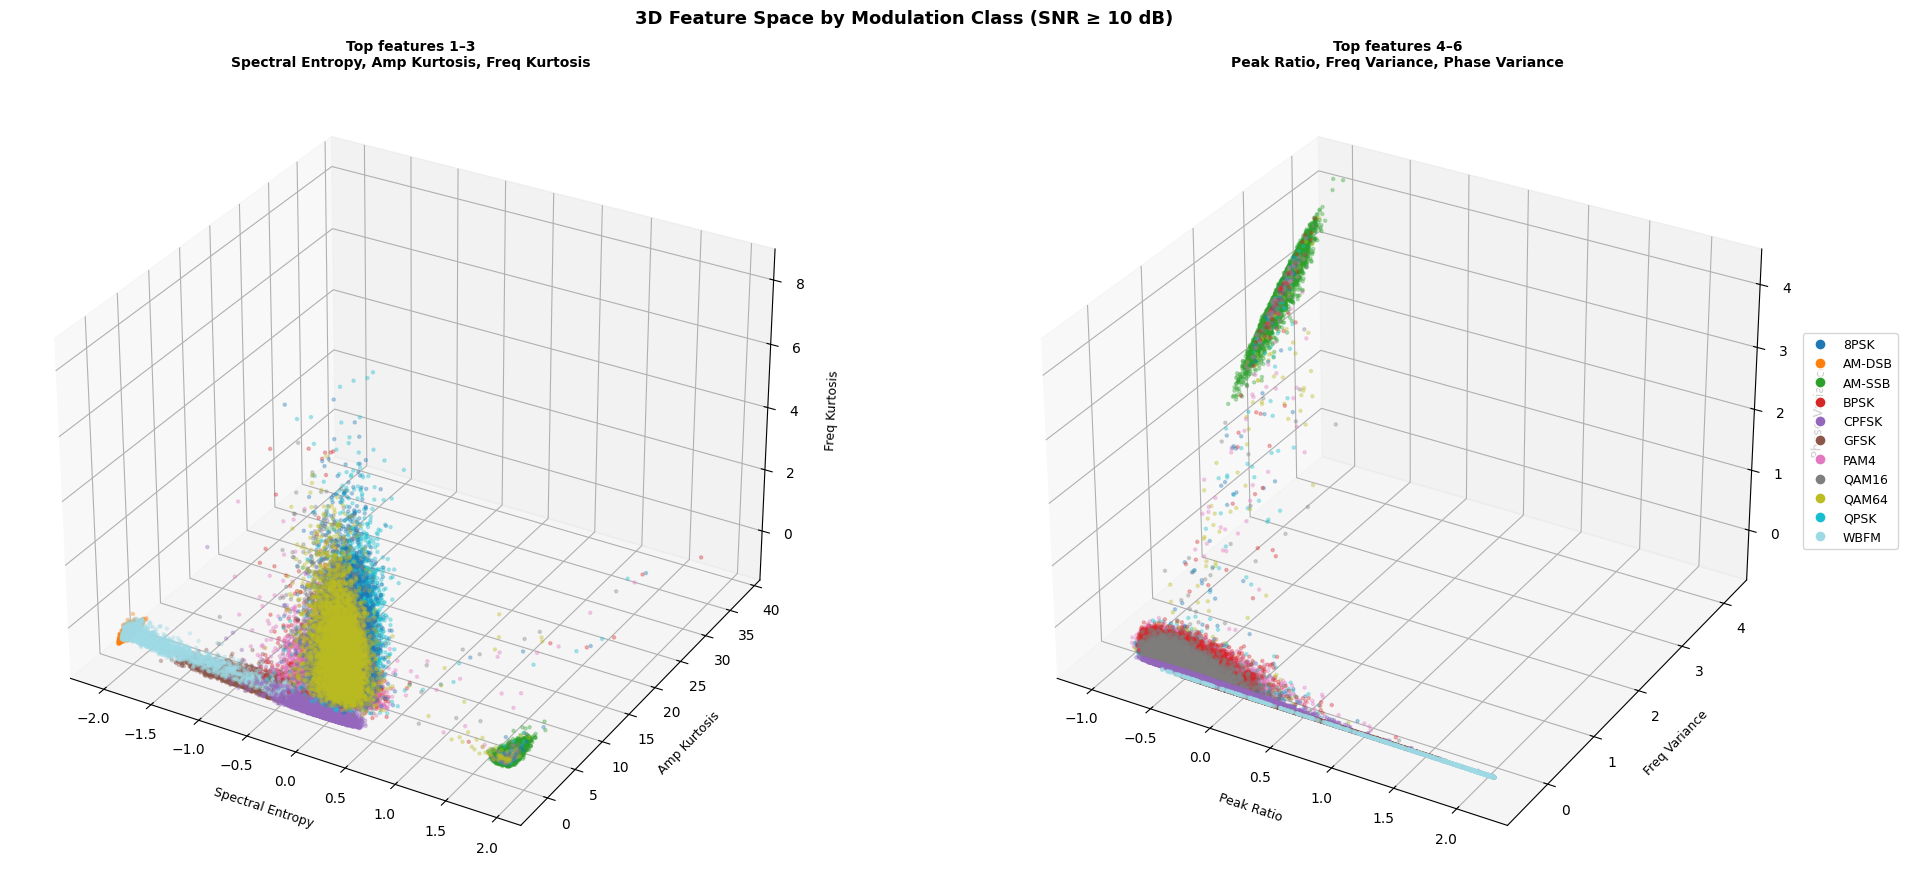

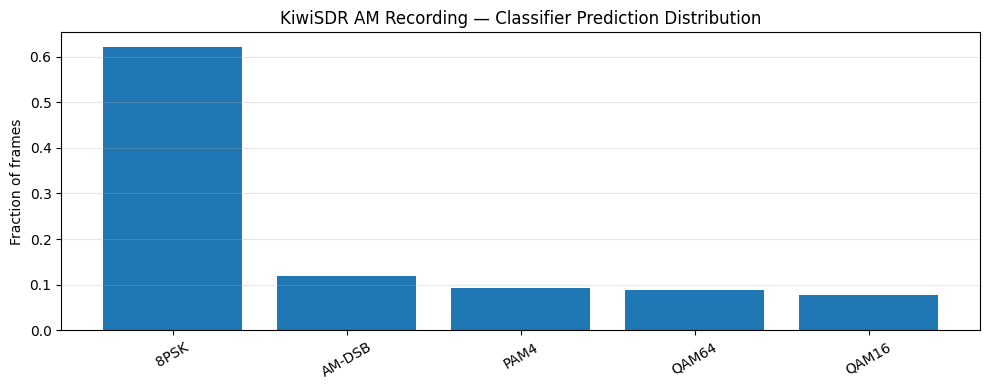

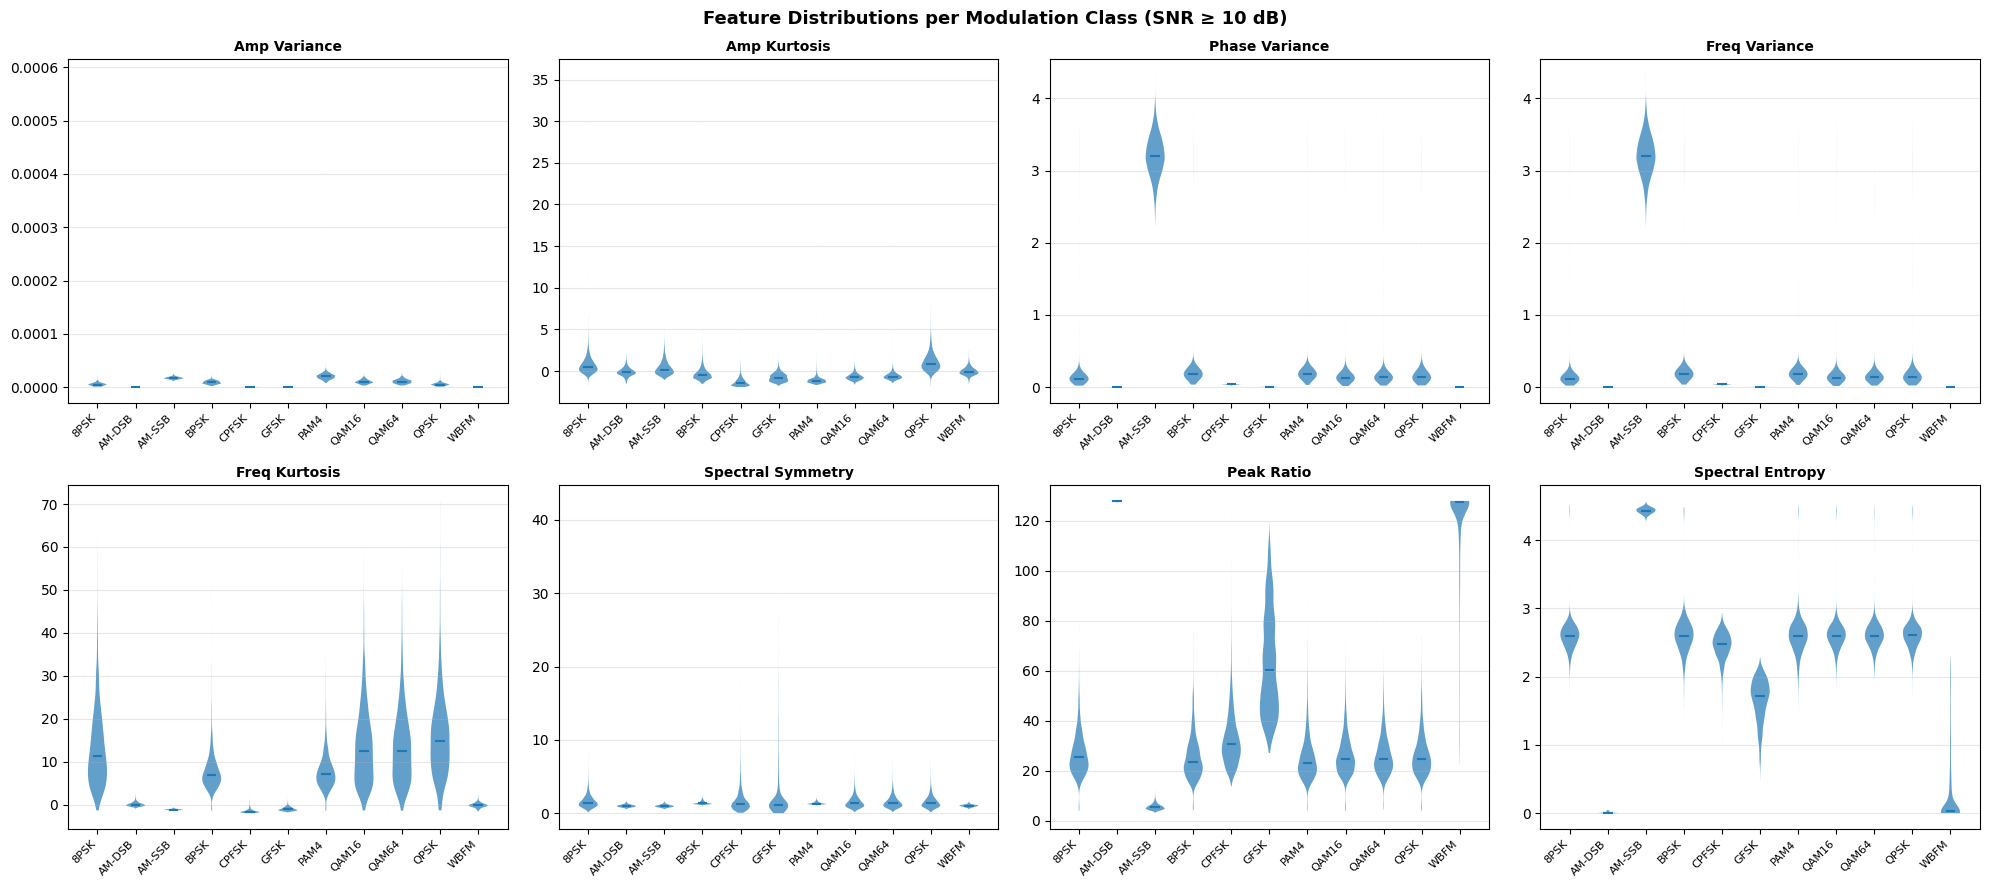

In [53]:
feature_names = [
    'Amp Variance', 'Amp Kurtosis', 'Phase Variance',
    'Freq Variance', 'Freq Kurtosis', 'Spectral Symmetry',
    'Peak Ratio', 'Spectral Entropy'
]

vis_mask = snr_labels >= 10
X_vis = X[vis_mask]
y_vis = y[vis_mask]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for feat_idx, (ax, fname) in enumerate(zip(axes, feature_names)):
    data_per_class = [X_vis[y_vis == mod, feat_idx] for mod in mods]
    parts = ax.violinplot(data_per_class, positions=range(len(mods)), showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_alpha(0.7)
    ax.set_xticks(range(len(mods)))
    ax.set_xticklabels(mods, rotation=45, ha='right', fontsize=8)
    ax.set_title(fname, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Feature Distributions per Modulation Class (SNR ≥ 10 dB)', fontsize=13, fontweight='bold')
plt.tight_layout()

## 4. Train / Test Split and SVM Training

We train only on high-SNR data (≥ 0 dB) where features are reliable, then test across all SNR levels to see how accuracy degrades under noise.

In [54]:
from sklearn.model_selection import train_test_split

snr_labels = np.asarray(snr_labels, dtype=int)
y = np.asarray(y)
X = np.asarray(X)

# High SNR only for training and validation
train_mask = snr_labels >= 0
X_hi, y_hi = X[train_mask], y[train_mask]

# 3-way split: 60% train / 20% val / 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_hi, y_hi, test_size=0.2, random_state=42, stratify=y_hi
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)
print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', decision_function_shape='ovr'))
])

import time
print("Training SVM...", end=" ", flush=True)
_t0 = time.time()
clf.fit(X_train, y_train)
print(f"done in {time.time() - _t0:.1f}s")
val_acc = accuracy_score(y_val, clf.predict(X_val))
print(f'Validation accuracy (SNR >= 0 dB): {val_acc:.3f}')

Train: 66000  Val: 22000  Test: 22000
Training SVM... done in 11.3s
Validation accuracy (SNR >= 0 dB): 0.742


## 5. Accuracy vs. SNR

The key result: how does classification accuracy vary with noise level?

Evaluating SNR levels:   0%|          | 0/20 [00:00<?, ?it/s]

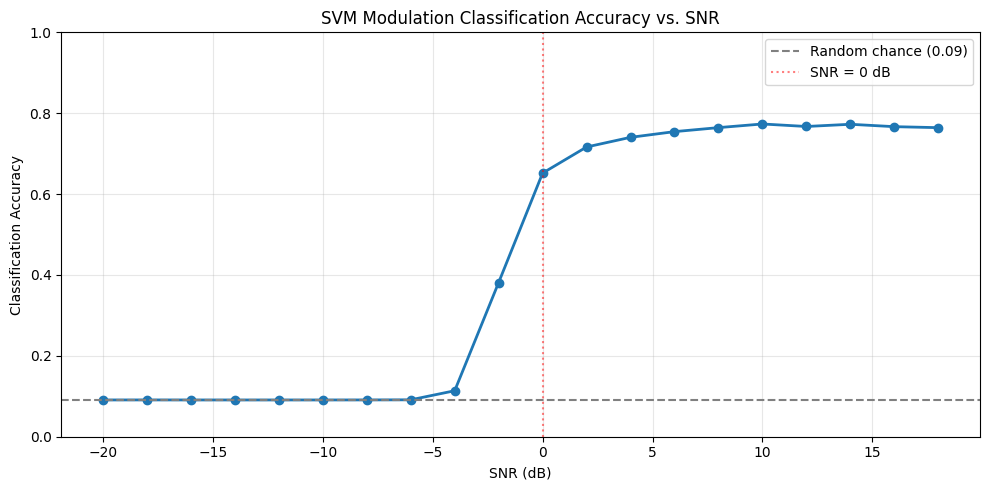

In [55]:
from tqdm.notebook import tqdm

accs = []
for snr in tqdm(snrs, desc="Evaluating SNR levels"):
    mask = snr_labels == snr
    if mask.sum() == 0:
        accs.append(np.nan)
        continue
    preds = clf.predict(X[mask])
    accs.append(accuracy_score(y[mask], preds))

plt.figure(figsize=(10, 5))
plt.plot(snrs, accs, 'o-', linewidth=2, markersize=6)
plt.axhline(1/len(mods), color='gray', linestyle='--', label=f'Random chance ({1/len(mods):.2f})')
plt.axvline(0, color='red', linestyle=':', alpha=0.5, label='SNR = 0 dB')
plt.xlabel('SNR (dB)')
plt.ylabel('Classification Accuracy')
plt.title('SVM Modulation Classification Accuracy vs. SNR')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()

## 6. Confusion Matrix

Which modulation types get confused with each other at high SNR?

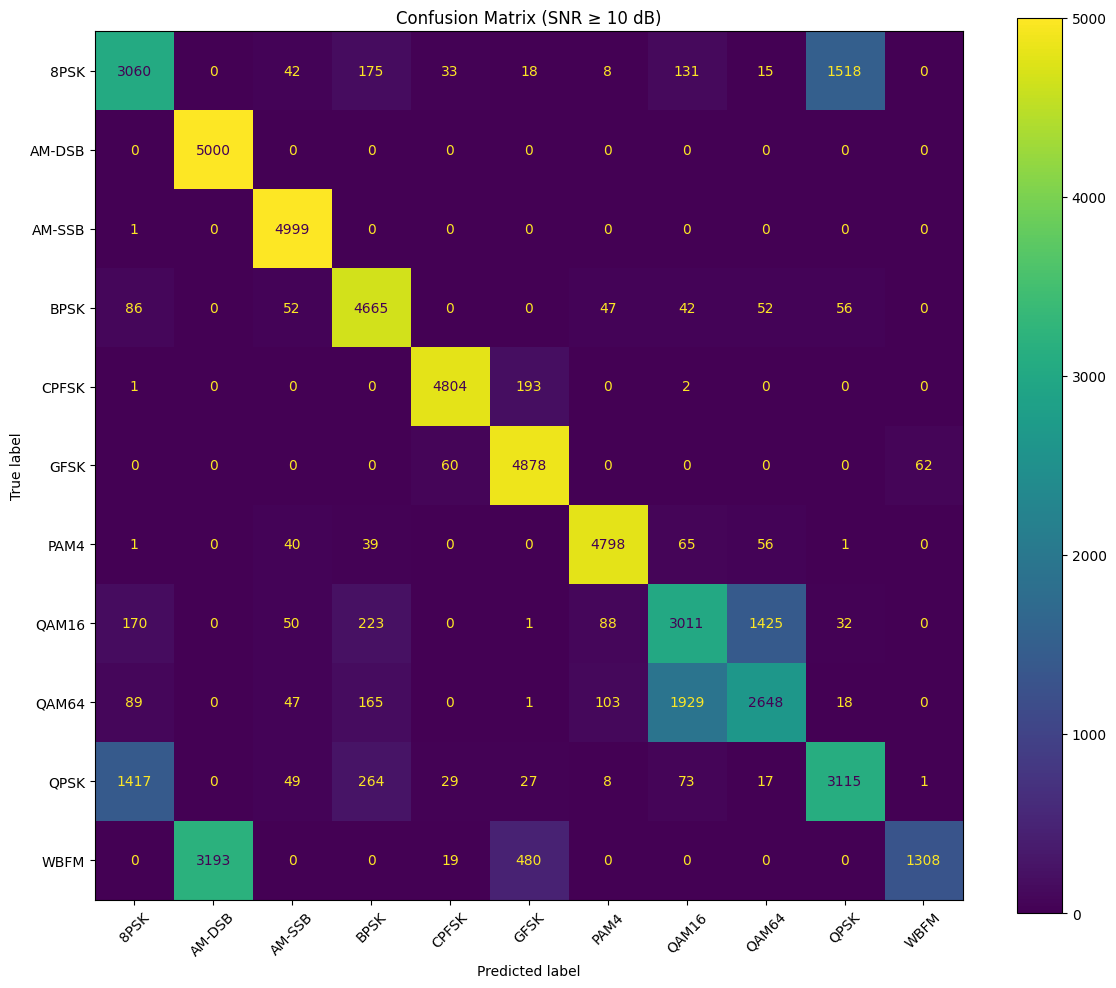

In [56]:
high_snr_mask = snr_labels >= 10
y_true = y[high_snr_mask]
y_pred = clf.predict(X[high_snr_mask])

cm = confusion_matrix(y_true, y_pred, labels=mods)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mods)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title('Confusion Matrix (SNR ≥ 10 dB)')
plt.tight_layout()

## 7. Feature Space Visualization (3D)

A Random Forest ranks the 8 features by importance. The top 6 are used to build two 3D scatter plots — one per feature triplet. Rotate the plots to explore class separation.

Ranking features... done in 0.3s

Feature importance ranking:
  Spectral Entropy    : 0.1802
  Freq Kurtosis       : 0.1675
  Amp Kurtosis        : 0.1503
  Peak Ratio          : 0.1380
  Phase Variance      : 0.1303
  Freq Variance       : 0.1215
  Amp Variance        : 0.0656
  Spectral Symmetry   : 0.0466


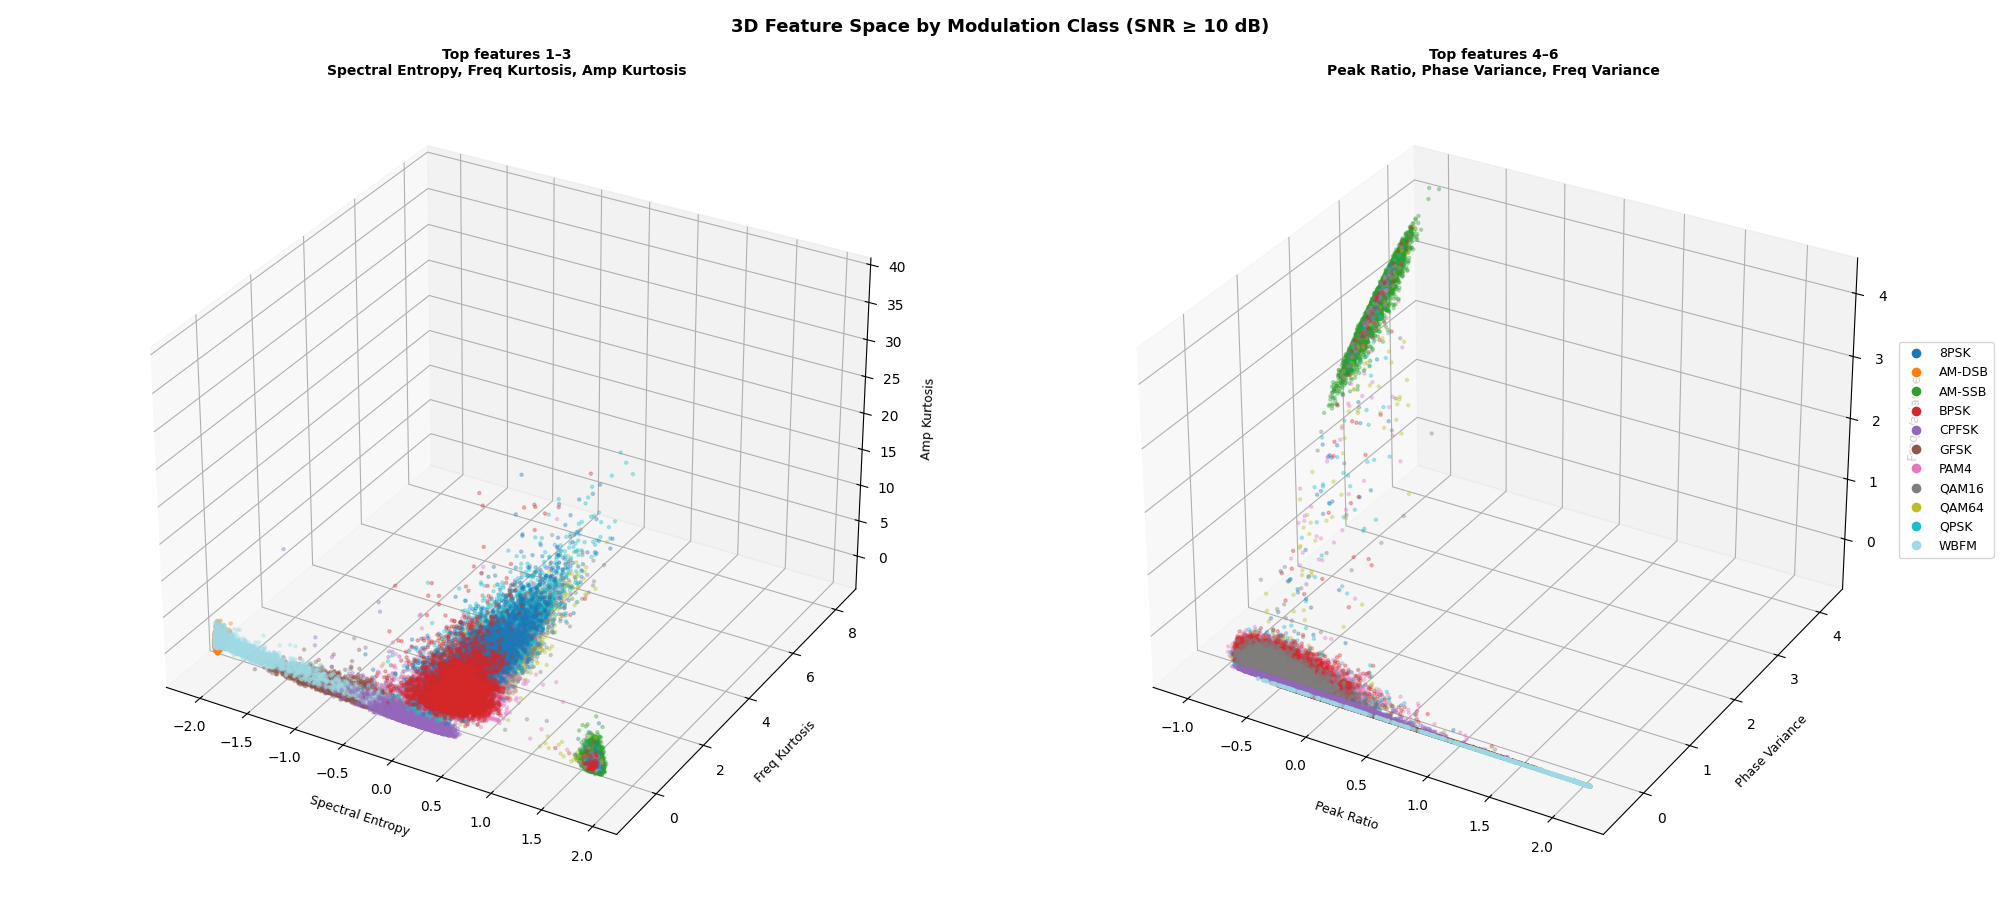

In [57]:
%matplotlib widget

from sklearn.ensemble import RandomForestClassifier
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Quick RF for feature importance ranking
print("Ranking features...", end=" ", flush=True)
import time
_t = time.time()
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"done in {time.time()-_t:.1f}s")

importances = rf.feature_importances_
ranked = np.argsort(importances)[::-1]

print("\nFeature importance ranking:")
for r in ranked:
    print(f"  {feature_names[r]:20s}: {importances[r]:.4f}")

# 3D scatter — top-3 and next-3 features
vis_mask = snr_labels >= 10
scaler = clf.named_steps['scaler']
X_scaled = scaler.transform(X[vis_mask])
y_vis = y[vis_mask]

colors = plt.cm.tab20(np.linspace(0, 1, len(mods)))
color_map = {mod: colors[i] for i, mod in enumerate(mods)}

fig = plt.figure(figsize=(20, 9))
for plot_idx, feat_trio in enumerate([ranked[:3], ranked[3:6]]):
    ax = fig.add_subplot(1, 2, plot_idx + 1, projection='3d')
    f0, f1, f2 = feat_trio
    for mod in mods:
        mask = y_vis == mod
        ax.scatter(X_scaled[mask, f0], X_scaled[mask, f1], X_scaled[mask, f2],
                   label=mod, alpha=0.3, s=5, color=color_map[mod])
    ax.set_xlabel(feature_names[f0], fontsize=9, labelpad=8)
    ax.set_ylabel(feature_names[f1], fontsize=9, labelpad=8)
    ax.set_zlabel(feature_names[f2], fontsize=9, labelpad=8)
    ax.set_title(f"Top features {plot_idx*3+1}–{plot_idx*3+3}\n"
                 f"{feature_names[f0]}, {feature_names[f1]}, {feature_names[f2]}",
                 fontsize=10, fontweight='bold')

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=color_map[m], markersize=8, label=m) for m in mods]
fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.0, 0.5), fontsize=9)
plt.suptitle('3D Feature Space by Modulation Class (SNR ≥ 10 dB)', fontsize=13, fontweight='bold')
plt.tight_layout()

## 8. Final Test Evaluation

Held-out test set (20% of high-SNR data, never seen during training or validation). This is the honest final accuracy.

In [58]:
test_acc = accuracy_score(y_test, clf.predict(X_test))
print(f"Final test accuracy (SNR >= 0 dB): {test_acc:.3f}")
print(f"Validation accuracy:               {val_acc:.3f}")
print(f"Random chance baseline:            {1/len(mods):.3f}")

# Per-class accuracy on test set
print("\nPer-class accuracy (test set, SNR >= 0 dB):")
for mod in mods:
    mask = y_test == mod
    acc = accuracy_score(y_test[mask], clf.predict(X_test[mask]))
    bar = '█' * int(acc * 20)
    print(f"  {mod:10s}: {acc:.3f} {bar}")

Final test accuracy (SNR >= 0 dB): 0.741
Validation accuracy:               0.742
Random chance baseline:            0.091

Per-class accuracy (test set, SNR >= 0 dB):
  8PSK      : 0.582 ███████████
  AM-DSB    : 0.971 ███████████████████
  AM-SSB    : 1.000 ███████████████████
  BPSK      : 0.882 █████████████████
  CPFSK     : 0.926 ██████████████████
  GFSK      : 0.951 ███████████████████
  PAM4      : 0.951 ███████████████████
  QAM16     : 0.588 ███████████
  QAM64     : 0.515 ██████████
  QPSK      : 0.522 ██████████
  WBFM      : 0.262 █████
